# Lewis Signalling Games

## Language as Convention

Why does the word *dog* mean what it means? Not because of any intrinsic connection between sound and animal — it's a **convention**: a self-reinforcing pattern of behaviour that, once adopted by a community, becomes stable.

In 1969, philosopher David Lewis formalised this idea with a simple game that captures the minimal conditions for linguistic convention to emerge from scratch.

## The Game

```
  world  ──state──→  [ SENDER ]  ──message──→  [ RECEIVER ]  ──action──→ ?
                                                                   ↓
                              shared reward  ←───── (action == state?)
```

Each **round**:
1. The world draws a **state** $s \in \{0,\ldots,N{-}1\}$ uniformly at random
2. The **Sender** sees $s$ and emits a **message** $m \in \{0,\ldots,N{-}1\}$
3. The **Receiver** sees only $m$ and takes an **action** $a \in \{0,\ldots,N{-}1\}$
4. Both receive reward $r = +1$ if $a = s$, else $r = -1$

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N_STATES   = 4
N_MESSAGES = 4
N_ROUNDS   = 4000

## Tabular Roth–Erev Agents

### Learning rule

$$W[i, j] \leftarrow W[i, j] + r \qquad P(j \mid i) = \frac{e^{W[i,j]}}{\sum_k e^{W[i,k]}}$$

Positive rewards increase the probability of the chosen action; negative rewards decrease it. All weights are initialised to a small constant $\varepsilon > 0$.

### Weight matrices

Each agent stores its learned tendencies in a 2-D weight matrix.

**Sender — `message_weights`**, shape `(N_STATES, N_MESSAGES)`

| | m0 | m1 | m2 | m3 |
|---|---|---|---|---|
| **s0** | W[0,0] | W[0,1] | W[0,2] | W[0,3] |
| **s1** | W[1,0] | W[1,1] | W[1,2] | W[1,3] |
| **s2** | W[2,0] | W[2,1] | W[2,2] | W[2,3] |
| **s3** | W[3,0] | W[3,1] | W[3,2] | W[3,3] |

- Each **row** = one world state $s$ the sender observed  
- Each **column** = one message $m$ the sender could emit  
- Entry $W[s, m]$ accumulates reward every time the sender emitted message $m$ while in state $s$

**Receiver — `action_weights`**, shape `(N_MESSAGES, N_ACTIONS)`

| | a0 | a1 | a2 | a3 |
|---|---|---|---|---|
| **m0** | W[0,0] | W[0,1] | W[0,2] | W[0,3] |
| **m1** | W[1,0] | W[1,1] | W[1,2] | W[1,3] |
| **m2** | W[2,0] | W[2,1] | W[2,2] | W[2,3] |
| **m3** | W[3,0] | W[3,1] | W[3,2] | W[3,3] |

- Each **row** = one message $m$ the receiver heard  
- Each **column** = one action $a$ the receiver could take  
- Entry $W[m, a]$ accumulates reward every time the receiver took action $a$ upon hearing message $m$

A large positive entry means the agent strongly favours that (row → column) pairing. A near-zero or negative entry means it rarely or never chose it (or it was punished).

**Example after partial training** (N = 4, invented numbers):

```
Sender message_weights          Receiver action_weights
         m0     m1     m2     m3           a0     a1     a2     a3
s0  [  8.4    0.1   -0.2    0.0 ]   m0 [  7.9    0.2   -0.1    0.1 ]
s1  [  0.2    7.8    0.1   -0.3 ]   m1 [  0.1    8.2    0.0   -0.2 ]
s2  [ -0.1    0.3    9.1    0.2 ]   m2 [ -0.3    0.0    8.7    0.1 ]
s3  [  0.1   -0.2    0.0    8.6 ]   m3 [  0.2   -0.1    0.3    9.0 ]
```

The large values on the diagonal show a one-to-one signalling system has emerged: $s0 \to m0 \to a0$, $s1 \to m1 \to a1$, etc.

In [15]:
class Sender:

    def __init__(self, n_states: int, n_messages: int, eps: float = 1e-6):
        self.n_messages = n_messages
        self.message_weights = np.full((n_states, n_messages), eps)
        self._last = (0, 0)

    def send_message(self, state: int) -> int:
        w = self.message_weights[state]
        w = w - w.max()  # subtract max for numerical stability before exp
        probs = np.exp(w) / np.exp(w).sum()
        message = rng.choice(self.n_messages, p=probs)
        self._last = (state, message)
        return message

    def learn_from_feedback(self, reward: int) -> None:
        self.message_weights[self._last] += reward


class Receiver:

    def __init__(self, n_messages: int, n_actions: int, eps: float = 1e-6):
        self.n_actions = n_actions
        self.action_weights = np.full((n_messages, n_actions), eps)
        self._last = (0, 0)

    def act(self, message: int) -> int:
        w = self.action_weights[message]
        w = w - w.max()  # subtract max for numerical stability before exp
        probs = np.exp(w) / np.exp(w).sum()
        action = rng.choice(self.n_actions, p=probs)
        self._last = (message, action)
        return action

    def learn_from_feedback(self, reward: int) -> None:
        self.action_weights[self._last] += reward


class World:

    def __init__(self, n_states: int):
        self.n_states = n_states
        self.state = 0

    def emit_state(self) -> int:
        self.state = rng.integers(self.n_states)
        return self.state

    def evaluate_action(self, action: int) -> int:
        return 1 if action == self.state else -1

### Task 1 — Training Loop

In [16]:
sender   = Sender(N_STATES, N_MESSAGES)
receiver = Receiver(N_MESSAGES, N_STATES)
world    = World(N_STATES)

reward_history = []
snapshots = {}
SNAP_AT = {0, N_ROUNDS // 4, N_ROUNDS // 2, N_ROUNDS - 1}

for epoch in range(N_ROUNDS):

    world_state = world.emit_state()
    message     = sender.send_message(world_state)
    action      = receiver.act(message)
    reward      = world.evaluate_action(action)

    # Task 1a: let both agents learn
    receiver.learn_from_feedback(reward)
    sender.learn_from_feedback(reward)

    # Task 1b: record the reward
    reward_history.append(reward)

    if epoch in SNAP_AT:
        snapshots[epoch] = {
            'sender':   sender.message_weights.copy(),
            'receiver': receiver.action_weights.copy(),
        }

print("Training complete.")
print(f"Final 200-round mean reward: {np.mean(reward_history[-200:]):.3f}  (perfect = 1.0)")

Training complete.
Final 200-round mean reward: 1.000  (perfect = 1.0)


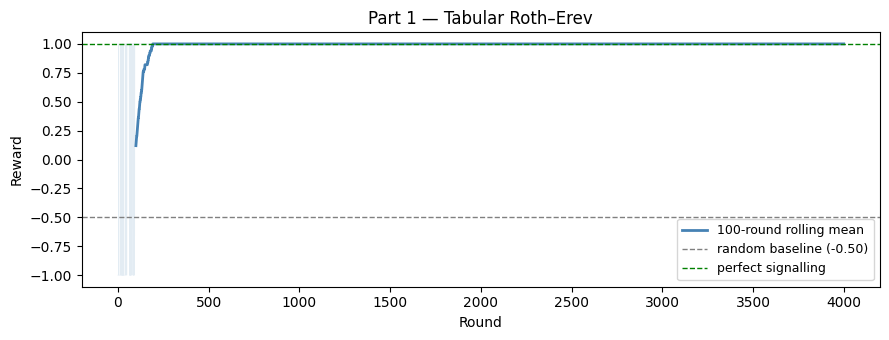

In [17]:
window = 100
smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(reward_history, alpha=0.15, color='steelblue', linewidth=0.5)
ax.plot(range(window - 1, N_ROUNDS), smoothed, color='steelblue', linewidth=2,
        label=f'{window}-round rolling mean')
ax.axhline(-1.0 + 2 / N_STATES, color='gray',  linestyle='--', linewidth=1,
           label=f'random baseline ({-1 + 2/N_STATES:.2f})')
ax.axhline(1.0, color='green', linestyle='--', linewidth=1, label='perfect signalling')
ax.set(xlabel='Round', ylabel='Reward', title='Part 1 — Tabular Roth–Erev')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Task 2 — Visualise the Signalling System

### Softmax

The weight matrices hold raw scores (arbitrary real numbers, growing with each reward). To act, each agent needs to convert a row of scores into a **probability distribution** over its choices — that is what softmax does.

For row $i$ with entries $w_{i,0},\, w_{i,1},\, \ldots,\, w_{i,K-1}$:

$$P(j \mid i) = \frac{e^{w_{i,j}}}{\displaystyle\sum_{k=0}^{K-1} e^{w_{i,k}}}$$

Key properties:
- Every output is in $(0, 1)$ — a strict probability
- All outputs in a row **sum to exactly 1**
- The option with the **highest weight gets the highest probability**, but all options keep some chance (exploration never fully stops)
- The mapping is **monotone**: doubling all weights does not change probabilities, but adding a constant to one entry does shift probability toward it

**Numerical stability.** Computing $e^w$ when $w$ is large (e.g. after thousands of positive rewards) causes floating-point overflow. The trick in the code is to subtract the row maximum first:

$$\frac{e^{w_j - c}}{\sum_k e^{w_k - c}} = \frac{e^{w_j}}{\sum_k e^{w_k}}, \qquad c = \max_k w_k$$

The constant $c$ cancels in numerator and denominator, so the result is identical — but now the largest exponent is always $e^0 = 1$, and nothing overflows.

In [18]:
def softmax_rows(W: np.ndarray) -> np.ndarray:
    """
    Apply row-wise softmax to weight matrix W.
    Returns an array of the same shape where each row is a probability distribution.
    """
    # Subtract row max for numerical stability before exponentiation
    W_stable = W - W.max(axis=1, keepdims=True)
    e = np.exp(W_stable)
    return e / e.sum(axis=1, keepdims=True)


test = np.array([[1.0, 2.0, 3.0]])
result = softmax_rows(test)
assert result.shape == test.shape
assert abs(result.sum() - 1.0) < 1e-9
print("softmax_rows OK:", result.round(3))

softmax_rows OK: [[0.09  0.245 0.665]]


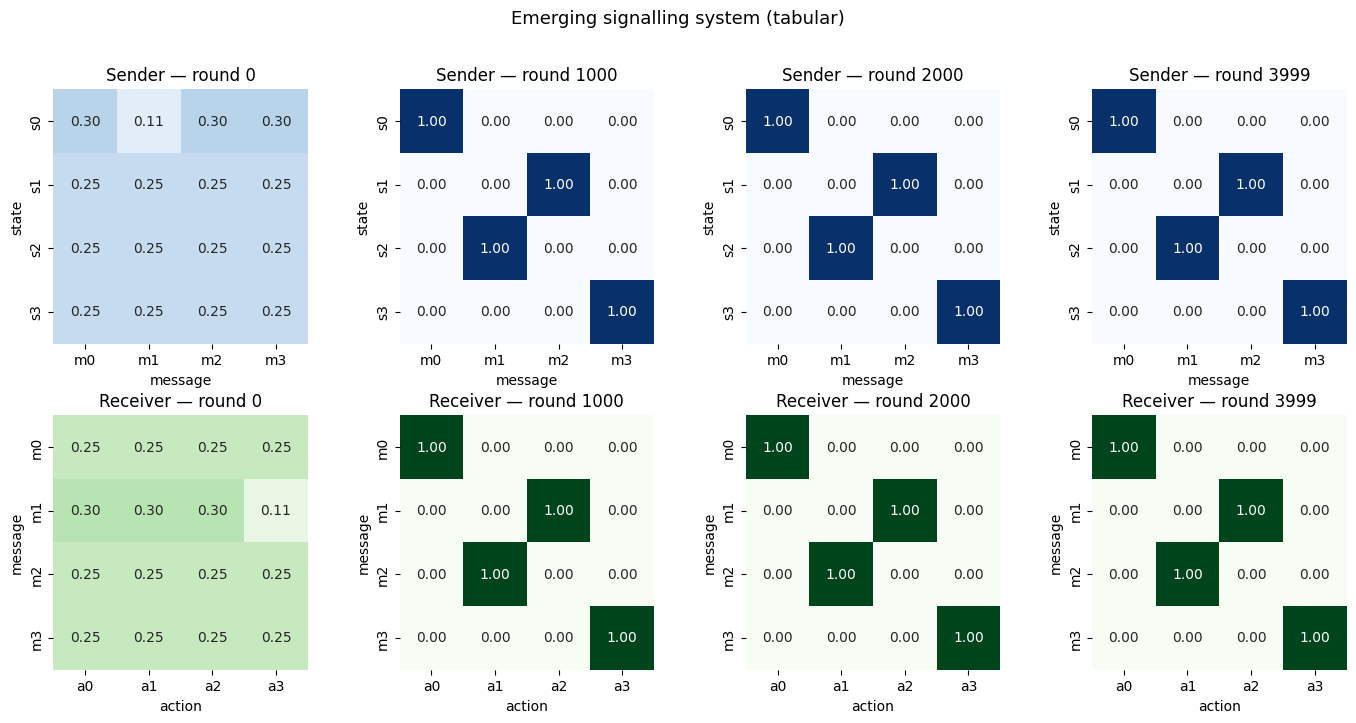

In [19]:
epochs = sorted(snapshots.keys())
fig, axes = plt.subplots(2, len(epochs), figsize=(3.5 * len(epochs), 7))

for col, ep in enumerate(epochs):
    snap = snapshots[ep]
    sender_probs   = softmax_rows(snap['sender'])
    receiver_probs = softmax_rows(snap['receiver'])

    kw = dict(annot=True, fmt='.2f', cbar=False, vmin=0, vmax=1, square=True)

    sns.heatmap(sender_probs, ax=axes[0, col],
                xticklabels=[f'm{i}' for i in range(N_MESSAGES)],
                yticklabels=[f's{i}' for i in range(N_STATES)],
                cmap='Blues', **kw)
    axes[0, col].set(title=f'Sender — round {ep}', xlabel='message', ylabel='state')

    sns.heatmap(receiver_probs, ax=axes[1, col],
                xticklabels=[f'a{i}' for i in range(N_STATES)],
                yticklabels=[f'm{i}' for i in range(N_MESSAGES)],
                cmap='Greens', **kw)
    axes[1, col].set(title=f'Receiver — round {ep}', xlabel='action', ylabel='message')

plt.suptitle('Emerging signalling system (tabular)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
final_sender_probs   = softmax_rows(sender.message_weights)
final_receiver_probs = softmax_rows(receiver.action_weights)

state_to_msg  = final_sender_probs.argmax(axis=1)
msg_to_action = final_receiver_probs.argmax(axis=1)

print("State  → message (sender argmax) :", state_to_msg)
print("Message → action  (receiver argmax):", msg_to_action)

composed = msg_to_action[state_to_msg]
is_valid = sorted(composed) == list(range(N_STATES))
print(f"\nState → action (composed): {composed}")
print(f"Valid signalling system: {is_valid}")

State  → message (sender argmax) : [0 2 1 3]
Message → action  (receiver argmax): [0 2 1 3]

State → action (composed): [0 1 2 3]
Valid signalling system: True


---
## Reflection Questions

1. **Arbitrariness of language.** Re-run the notebook with a different random seed (change `rng = np.random.default_rng(42)`). Do you get the same signalling system? What does this tell you about the relationship between form and meaning?

2. **Convergence speed.** How does the number of states $N$ affect the number of rounds needed to converge? Try `N_STATES = 6` and `N_STATES = 10`. Is the relationship linear or faster?

3. **Underspecified vocabulary.** Set `N_MESSAGES = 2` with `N_STATES = 4`. A perfect signalling system is now impossible — the sender cannot uniquely identify all states with only 2 signals. What is the theoretical maximum reward? What strategy do the agents adopt?

4. **Symmetry breaking.** At the start of training all weights are equal (initialised to $\varepsilon$). What breaks the symmetry and drives agents towards one particular signalling system rather than another?

5. **Negative reward.** The current reward scheme is $+1$ for success and $-1$ for failure. What would change if you used $0$ and $+1$ instead? Would the agents still learn? Would they learn faster or slower?